In [ ]:
import pandas as pd

# Import
url = "https://drive.google.com/uc?id=1lpt8x9CFUsQzrjLysTSLS4WBEUAS-6oN"
df_raw = pd.read_csv(url)

<>:18: SyntaxWarning: invalid escape sequence '\.'
<>:18: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_7091/2947680112.py:18: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


JENIS KERNEL              | AKURASI   
----------------------------------------
Linear SVM                | 78.21%
Non-Linear SVM (RBF)      | 81.56%

--- Laporan Detail Linear SVM ---
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       105
           1       0.75      0.70      0.73        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179


--- Laporan Detail Non-Linear SVM (RBF) ---
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179



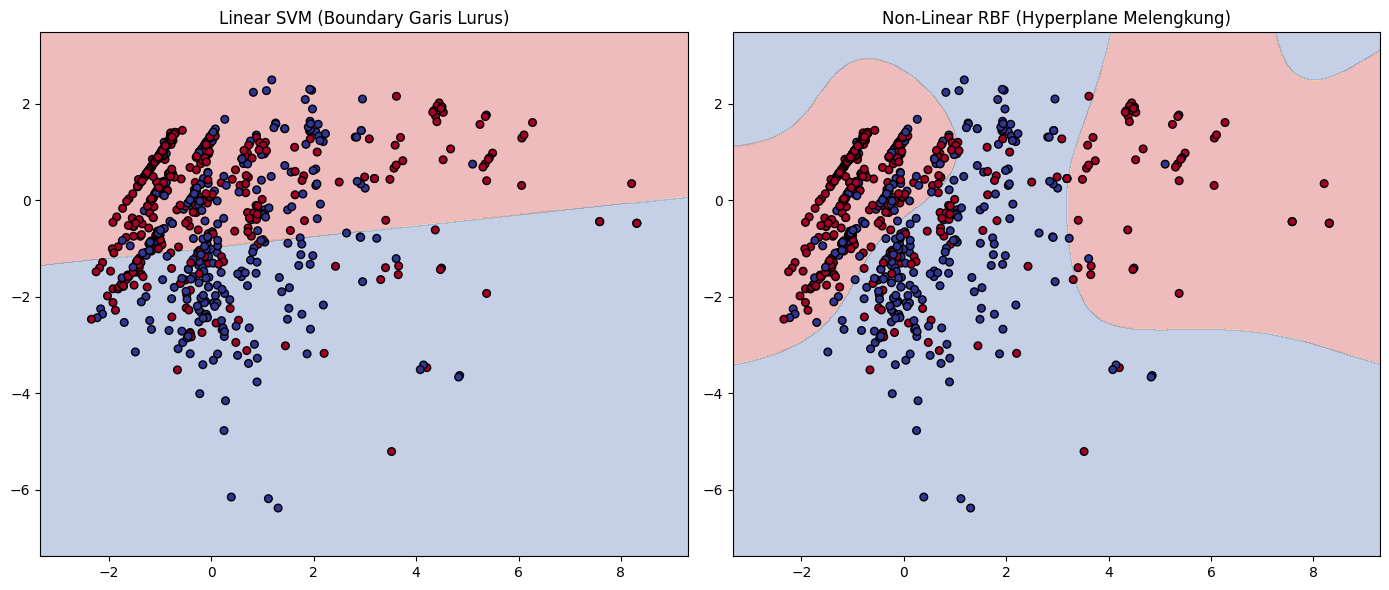

In [12]:
 import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report

# 1. Load Data dari Drive
url = "https://drive.google.com/uc?id=1lpt8x9CFUsQzrjLysTSLS4WBEUAS-6oN"
df = pd.read_csv(url)

# 2. FEATURE ENGINEERING (Kunci peningkat akurasi)
# Ekstrak Gelar (Mr, Mrs, Miss, Master, dll)
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss').replace('Ms', 'Miss').replace('Mme', 'Mrs')

# Fitur Keluarga
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Preprocessing: Mapping kategori ke angka
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'].fillna('S'))
df['Title'] = le.fit_transform(df['Title'])

# Pilih fitur yang sudah diperkaya
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Title', 'FamilySize', 'SibSp', 'Parch']
X = df[features]
y = df['Survived']

# Handling missing values & Scaling (Penting untuk SVM)
X = SimpleImputer(strategy='median').fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA untuk visualisasi 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# 4. TUNING PARAMETER
# Menaikkan C (Regularization) membantu Linear SVM mencari margin lebih baik
model_linear = SVC(kernel='linear', C=10.0)
# RBF menggunakan C lebih tinggi dan Gamma spesifik untuk fleksibilitas
model_rbf = SVC(kernel='rbf', C=5.0, gamma=0.1)

# Training untuk hasil teks
model_linear.fit(X_train, y_train)
model_rbf.fit(X_train, y_train)

# 5. OUTPUT HASIL
y_pred_lin = model_linear.predict(X_test)
y_pred_rbf = model_rbf.predict(X_test)

print(f"{'JENIS KERNEL':<25} | {'AKURASI':<10}")
print("-" * 40)
print(f"{'Linear SVM':<25} | {accuracy_score(y_test, y_pred_lin):.2%}")
print(f"{'Non-Linear SVM (RBF)':<25} | {accuracy_score(y_test, y_pred_rbf):.2%}")

print("\n--- Laporan Detail Linear SVM ---")
print(classification_report(y_test, y_pred_lin))

print("\n--- Laporan Detail Non-Linear SVM (RBF) ---")
print(classification_report(y_test, y_pred_rbf))

# 6. VISUALISASI GRAPH (Linear vs Hyperplane)
def plot_decision_boundary(model, X_data, y_data, ax, title):
    h = .02
    x_min, x_max = X_data[:, 0].min() - 1, X_data[:, 0].max() + 1
    y_min, y_max = X_data[:, 1].min() - 1, X_data[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    ax.scatter(X_data[:, 0], X_data[:, 1], c=y_data, edgecolors='k', s=30, cmap='RdYlBu')
    ax.set_title(title)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Training ulang pada PCA data untuk visualisasi
model_linear.fit(X_train_p, y_train_p)
plot_decision_boundary(model_linear, X_pca, y, ax1, "Linear SVM (Boundary Garis Lurus)")

model_rbf.fit(X_train_p, y_train_p)
plot_decision_boundary(model_rbf, X_pca, y, ax2, "Non-Linear RBF (Hyperplane Melengkung)")

plt.tight_layout()
plt.show()